In [5]:
#import
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


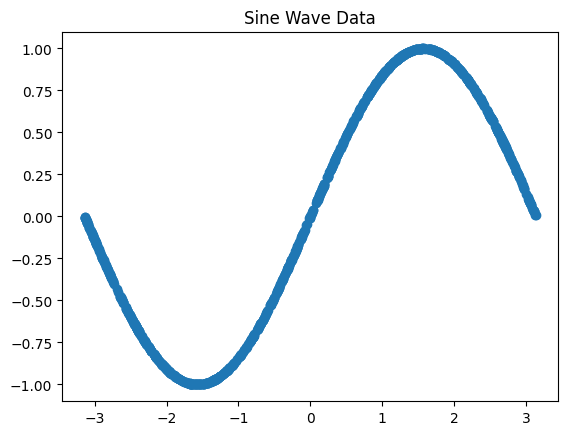

In [6]:
#sine dataset
x = np.random.uniform(-np.pi, np.pi, 1000)
y = np.sin(x)

data = torch.tensor(np.vstack((x, y)).T, dtype=torch.float32).to(device)

plt.scatter(x, y)
plt.title("Sine Wave Data")
plt.show()

In [7]:
#generator and discriminator
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 128),
            nn.ReLU(),
            nn.Linear(128, 2)
        )

    def forward(self, x):
        return self.net(x)


class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 64),
            nn.LeakyReLU(0.2),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

In [8]:
#train gan
G = Generator().to(device)
D = Discriminator().to(device)

loss_fn = nn.BCELoss()
g_opt = optim.Adam(G.parameters(), lr=0.001)
d_opt = optim.Adam(D.parameters(), lr=0.001)

for epoch in range(500):

    z = torch.randn(len(data), 2).to(device)
    fake = G(z)

    real_labels = torch.ones(len(data), 1).to(device)
    fake_labels = torch.zeros(len(data), 1).to(device)

    # Discriminator
    d_loss = loss_fn(D(data), real_labels) + loss_fn(D(fake.detach()), fake_labels)

    d_opt.zero_grad()
    d_loss.backward()
    d_opt.step()

    # Generator
    g_loss = loss_fn(D(fake), real_labels)

    g_opt.zero_grad()
    g_loss.backward()
    g_opt.step()

print("Training complete (Sine GAN)")

Training complete (Sine GAN)


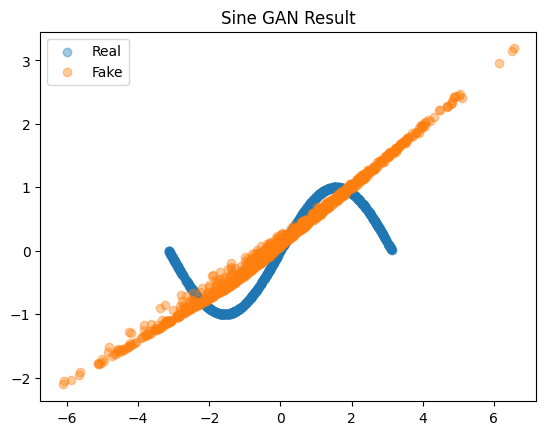

In [9]:
#visualize result
z = torch.randn(1000, 2).to(device)
fake = G(z).detach().cpu()

plt.scatter(data[:,0].cpu(), data[:,1].cpu(), alpha=0.4, label="Real")
plt.scatter(fake[:,0], fake[:,1], alpha=0.4, label="Fake")
plt.legend()
plt.title("Sine GAN Result")
plt.show()

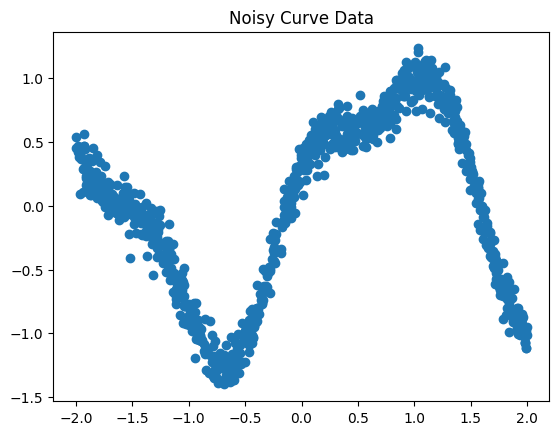

In [10]:
#create dataset
x2 = np.random.uniform(-2, 2, 1000)
y2 = np.sin(2*x2) + 0.3*np.cos(5*x2) + np.random.normal(0, 0.1, 1000)

data2 = torch.tensor(np.vstack((x2, y2)).T, dtype=torch.float32).to(device)

plt.scatter(x2, y2)
plt.title("Noisy Curve Data")
plt.show()

In [11]:
#train gan
G2 = Generator().to(device)
D2 = Discriminator().to(device)

g_opt2 = optim.Adam(G2.parameters(), lr=0.001)
d_opt2 = optim.Adam(D2.parameters(), lr=0.001)

loss_fn = nn.BCELoss()

for epoch in range(500):

    z = torch.randn(len(data2), 2).to(device)
    fake = G2(z)

    real_labels = torch.ones(len(data2), 1).to(device)
    fake_labels = torch.zeros(len(data2), 1).to(device)

    d_loss = loss_fn(D2(data2), real_labels) + loss_fn(D2(fake.detach()), fake_labels)

    d_opt2.zero_grad()
    d_loss.backward()
    d_opt2.step()

    g_loss = loss_fn(D2(fake), real_labels)

    g_opt2.zero_grad()
    g_loss.backward()
    g_opt2.step()

print("Training complete (Noisy Curve GAN)")

Training complete (Noisy Curve GAN)


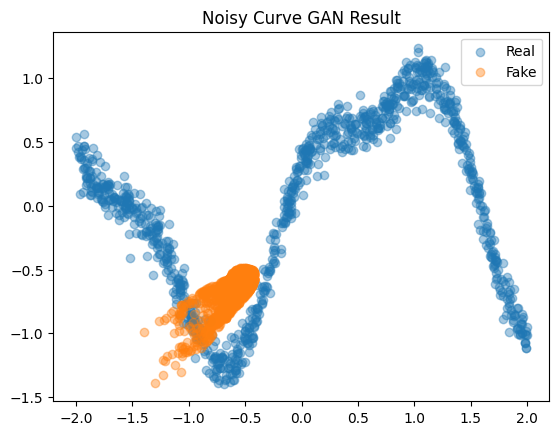

In [12]:
#result
z = torch.randn(1000, 2).to(device)
fake2 = G2(z).detach().cpu()

plt.scatter(data2[:,0].cpu(), data2[:,1].cpu(), alpha=0.4, label="Real")
plt.scatter(fake2[:,0], fake2[:,1], alpha=0.4, label="Fake")
plt.legend()
plt.title("Noisy Curve GAN Result")
plt.show()

In [13]:
#improved genearator
class Generator_Mod(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 2)
        )

    def forward(self, x):
        return self.net(x)

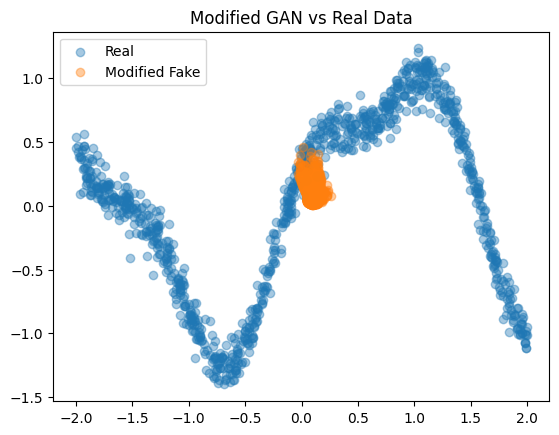

In [14]:
#compare generator
G_mod = Generator_Mod().to(device)

z = torch.randn(1000, 2).to(device)
fake_mod = G_mod(z).detach().cpu()

plt.scatter(data2[:,0].cpu(), data2[:,1].cpu(), alpha=0.4, label="Real")
plt.scatter(fake_mod[:,0], fake_mod[:,1], alpha=0.4, label="Modified Fake")
plt.legend()
plt.title("Modified GAN vs Real Data")
plt.show()

PART 2.1: BloodMNIST

In [ ]:
from medmnist import BloodMNIST
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize(32),
    transforms.Normalize((0.5,), (0.5,))
])

dataset = BloodMNIST(split="train", download=True, transform=transform)
loader = DataLoader(dataset, batch_size=64, shuffle=True)

print("Dataset size:", len(dataset))
print("Class distribution:", np.bincount(dataset.labels.flatten()))

Dataset size: 11959
Class distribution: [ 852 2181 1085 2026  849  993 2330 1643]


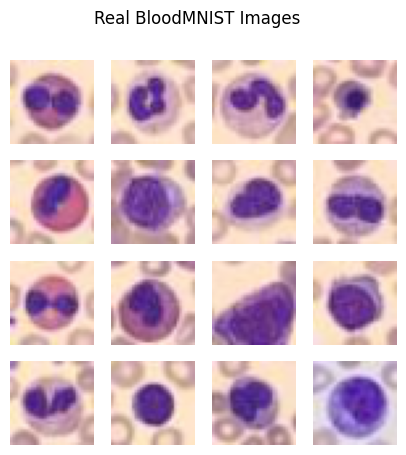

In [ ]:
#real images
images = next(iter(loader))[0][:16]

fig, axes = plt.subplots(4,4, figsize=(5,5))

for i, ax in enumerate(axes.flatten()):
    img = (images[i] + 1) / 2
    ax.imshow(img.permute(1,2,0))
    ax.axis("off")

plt.suptitle("Real BloodMNIST Images")
plt.show()

In [ ]:
#dcgan
import torch
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose2d(100, 256, 4, 1, 0, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(),

            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.ConvTranspose2d(64, 3, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, x):
        return self.net(x)


class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 64, 4, 2, 1),
            nn.LeakyReLU(0.2),

            nn.Conv2d(64, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),

            nn.Flatten(),
            nn.Linear(128*8*8, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

In [ ]:
#train
import torch.optim as optim

G = Generator().to(device)
D = Discriminator().to(device)

loss_fn = nn.BCELoss()

g_opt = optim.Adam(G.parameters(), lr=0.0002, betas=(0.5,0.999))
d_opt = optim.Adam(D.parameters(), lr=0.0002, betas=(0.5,0.999))

g_losses = []
d_losses = []

epochs = 5

for epoch in range(epochs):
    for real,_ in loader:
        real = real.to(device)
        bs = real.size(0)

        real_y = torch.ones(bs,1).to(device)
        fake_y = torch.zeros(bs,1).to(device)

        # --- Train D ---
        z = torch.randn(bs,100,1,1).to(device)
        fake = G(z)

        d_loss = loss_fn(D(real), real_y) + loss_fn(D(fake.detach()), fake_y)

        d_opt.zero_grad()
        d_loss.backward()
        d_opt.step()

        # --- Train G ---
        z = torch.randn(bs,100,1,1).to(device)
        fake = G(z)

        g_loss = loss_fn(D(fake), real_y)

        g_opt.zero_grad()
        g_loss.backward()
        g_opt.step()

    g_losses.append(g_loss.item())
    d_losses.append(d_loss.item())

    print(f"Epoch {epoch+1} | D: {d_loss.item():.4f} | G: {g_loss.item():.4f}")

Epoch 1 | D: 0.4795 | G: 2.9128
Epoch 2 | D: 0.1291 | G: 3.2315
Epoch 3 | D: 0.2893 | G: 2.7575
Epoch 4 | D: 0.2472 | G: 2.6194
Epoch 5 | D: 0.5976 | G: 1.5905


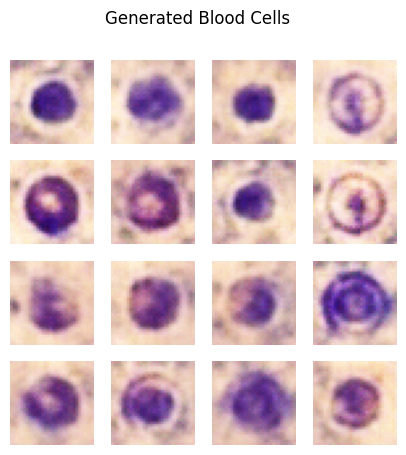

In [ ]:
#generate images
G.eval()

z = torch.randn(16,100,1,1).to(device)
fake = G(z).detach().cpu()

fig, axes = plt.subplots(4,4, figsize=(5,5))

for i, ax in enumerate(axes.flatten()):
    img = (fake[i] + 1) / 2
    ax.imshow(img.permute(1,2,0))
    ax.axis("off")

plt.suptitle("Generated Blood Cells")
plt.show()

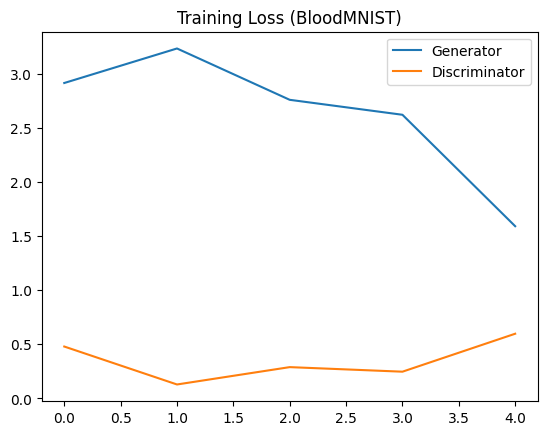

In [ ]:
#loss curve
import matplotlib.pyplot as plt

plt.plot(g_losses, label="Generator")
plt.plot(d_losses, label="Discriminator")

plt.legend()
plt.title("Training Loss (BloodMNIST)")
plt.show()

In [ ]:
#fid
real = images[:16].view(16,-1).cpu().numpy()
fake = fake.view(16,-1).numpy()

fid = np.linalg.norm(real.mean(axis=0) - fake.mean(axis=0))

print("Approx FID:", fid)

Approx FID: 5.0436077


PART 2.2: CICIDS

In [ ]:
#load dataset
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import torch

df = pd.read_csv("Wednesday-workingHours.pcap_ISCX.csv")

df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)

data = df.select_dtypes(include=[np.number])
data = MinMaxScaler().fit_transform(data)

data = torch.tensor(data, dtype=torch.float32).to(device)
dim = data.shape[1]

In [ ]:
#gan
class G_tab(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(100,128),
            nn.ReLU(),
            nn.Linear(128,dim),
            nn.Sigmoid()
        )

    def forward(self,x):
        return self.net(x)


class D_tab(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim,128),
            nn.LeakyReLU(0.2),
            nn.Linear(128,1),
            nn.Sigmoid()
        )

    def forward(self,x):
        return self.net(x)

In [ ]:
#train
from sklearn.decomposition import PCA

Gt = G_tab().to(device)
Dt = D_tab().to(device)

loss_fn = nn.BCELoss()

g_opt = optim.Adam(Gt.parameters(), 0.0002)
d_opt = optim.Adam(Dt.parameters(), 0.0002)

g_losses = []
d_losses = []

for _ in range(200):

    idx = torch.randint(0, data.size(0), (64,))
    real = data[idx]

    z = torch.randn(64,100).to(device)
    fake = Gt(z)

    real_y = torch.ones(64,1).to(device)
    fake_y = torch.zeros(64,1).to(device)

    d_loss = loss_fn(Dt(real), real_y) + loss_fn(Dt(fake.detach()), fake_y)

    d_opt.zero_grad()
    d_loss.backward()
    d_opt.step()

    g_loss = loss_fn(Dt(fake), real_y)

    g_opt.zero_grad()
    g_loss.backward()
    g_opt.step()

    g_losses.append(g_loss.item())
    d_losses.append(d_loss.item())

print("CICIDS training complete")

CICIDS training complete


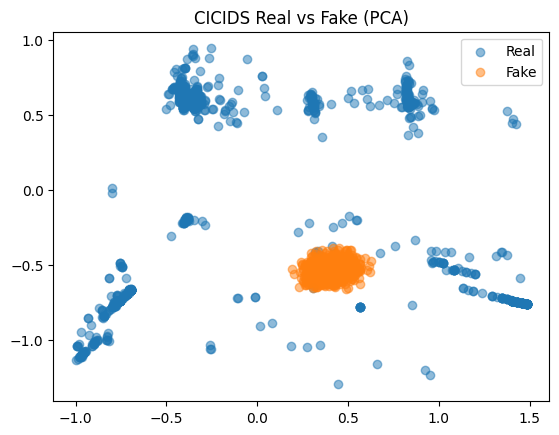

In [ ]:
#pca
real_np = data[:1000].cpu().numpy()
fake_np = Gt(torch.randn(1000,100).to(device)).detach().cpu().numpy()

pca = PCA(n_components=2)

r = pca.fit_transform(real_np)
f = pca.transform(fake_np)

plt.scatter(r[:,0], r[:,1], alpha=0.5, label="Real")
plt.scatter(f[:,0], f[:,1], alpha=0.5, label="Fake")

plt.legend()
plt.title("CICIDS Real vs Fake (PCA)")
plt.show()

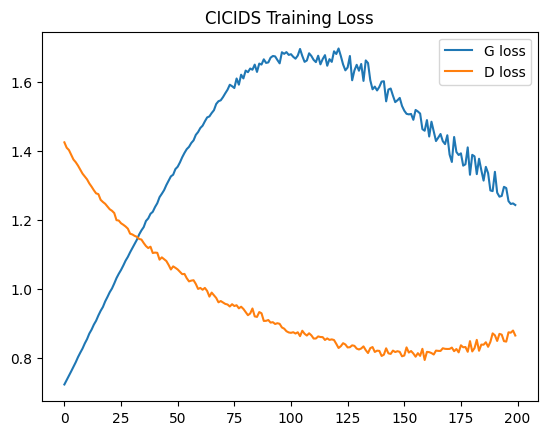

In [ ]:
#loss curve
plt.plot(g_losses, label="G loss")
plt.plot(d_losses, label="D loss")

plt.legend()
plt.title("CICIDS Training Loss")
plt.show()

PART 2.3: Pizza GAN

In [ ]:
import numpy as np
from quickdraw import QuickDrawDataGroup

qd = QuickDrawDataGroup("pizza")

images = []
for i, d in enumerate(qd.drawings):
    img = d.get_image().resize((28, 28)).convert("L")
    images.append(np.array(img))

    if i == 3000:   # limit for speed
        break

images = np.array(images)
print("Dataset shape:", images.shape)

loading pizza drawings
load complete
Dataset shape: (1000, 28, 28)


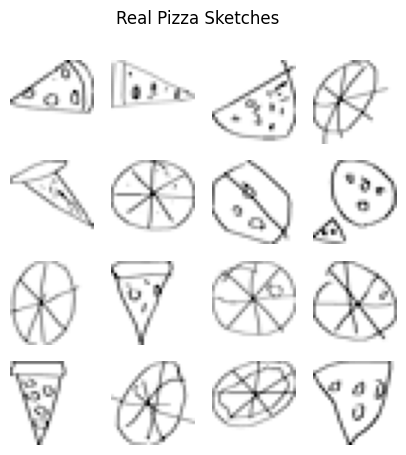

In [ ]:
#visualize
import matplotlib.pyplot as plt

fig, axes = plt.subplots(4,4, figsize=(5,5))

for i, ax in enumerate(axes.flatten()):
    ax.imshow(images[i], cmap="gray")
    ax.axis("off")

plt.suptitle("Real Pizza Sketches")
plt.show()

In [ ]:
#preprocess
import torch
from torch.utils.data import DataLoader, TensorDataset

# normalize to [-1,1]
images = (images / 127.5) - 1

# convert to tensor
data = torch.tensor(images).unsqueeze(1).float()

loader = DataLoader(TensorDataset(data), batch_size=64, shuffle=True)

print("Tensor shape:", data.shape)

Tensor shape: torch.Size([1000, 1, 28, 28])


In [ ]:
import torch.nn as nn

class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose2d(100, 256, 4, 1, 0), # Output: (batch_size, 256, 4, 4)
            nn.BatchNorm2d(256),
            nn.ReLU(),

            nn.ConvTranspose2d(256, 128, 3, 2, 1), # Output: (batch_size, 128, 7, 7)
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.ConvTranspose2d(128, 64, 4, 2, 1), # Output: (batch_size, 64, 14, 14)
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.ConvTranspose2d(64, 1, 4, 2, 1),  # Output: (batch_size, 1, 28, 28)
            nn.Tanh()
        )

    def forward(self, x):
        return self.net(x)

In [ ]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 64, 4, 2, 1), # Input: (batch_size, 1, 28, 28) -> Output: (batch_size, 64, 14, 14)
            nn.LeakyReLU(0.2),

            nn.Conv2d(64, 128, 4, 2, 1), # Input: (batch_size, 64, 14, 14) -> Output: (batch_size, 128, 7, 7)
            nn.BatchNorm2d(128), # Added for consistency and better performance
            nn.LeakyReLU(0.2),

            nn.Flatten(), # Output: (batch_size, 128 * 7 * 7)
            nn.Linear(128 * 7 * 7, 1), # Corrected from 128 * 8 * 8 to 128 * 7 * 7 for 28x28 input
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

In [ ]:
#train
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

G = Generator().to(device)
D = Discriminator().to(device)

loss_fn = nn.BCELoss()
g_opt = optim.Adam(G.parameters(), lr=0.0002)
d_opt = optim.Adam(D.parameters(), lr=0.0002)

epochs = 10

for epoch in range(epochs):
    for (real,) in loader:
        real = real.to(device)
        bs = real.size(0)

        real_labels = torch.ones(bs,1).to(device)
        fake_labels = torch.zeros(bs,1).to(device)

        # Train Discriminator
        z = torch.randn(bs,100,1,1).to(device)
        fake = G(z)

        d_loss = loss_fn(D(real), real_labels) + \
                 loss_fn(D(fake.detach()), fake_labels)

        d_opt.zero_grad()
        d_loss.backward()
        d_opt.step()

        # Train Generator
        z = torch.randn(bs,100,1,1).to(device)
        fake = G(z)

        g_loss = loss_fn(D(fake), real_labels)

        g_opt.zero_grad()
        g_loss.backward()
        g_opt.step()

    print(f"Epoch {epoch+1}/{epochs} | D Loss: {d_loss.item():.4f} | G Loss: {g_loss.item():.4f}")

Epoch 1/10 | D Loss: 0.0962 | G Loss: 3.3282
Epoch 2/10 | D Loss: 0.0260 | G Loss: 4.7594
Epoch 3/10 | D Loss: 0.0256 | G Loss: 4.3801
Epoch 4/10 | D Loss: 0.0056 | G Loss: 6.6830
Epoch 5/10 | D Loss: 0.0058 | G Loss: 7.3061
Epoch 6/10 | D Loss: 0.0070 | G Loss: 5.3434
Epoch 7/10 | D Loss: 0.0098 | G Loss: 5.1685
Epoch 8/10 | D Loss: 0.0067 | G Loss: 5.5302
Epoch 9/10 | D Loss: 0.0063 | G Loss: 5.6854
Epoch 10/10 | D Loss: 0.0045 | G Loss: 5.9542


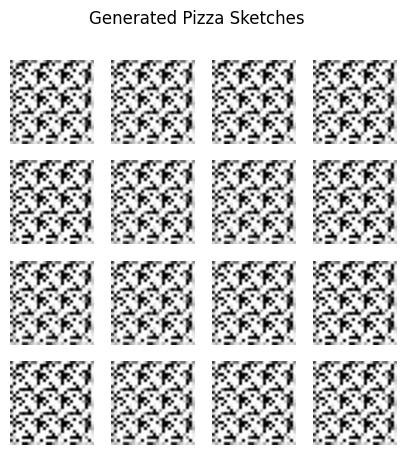

In [ ]:
#generate
z = torch.randn(16, 100, 1, 1).to(device)
fake = G(z).detach().cpu()

import matplotlib.pyplot as plt

fig, axes = plt.subplots(4,4, figsize=(5,5))

for i, ax in enumerate(axes.flatten()):
    ax.imshow((fake[i][0].numpy() + 1) / 2, cmap="gray")
    ax.axis("off")

plt.suptitle("Generated Pizza Sketches")
plt.show()